# **FYP Sales Forecasting Model Building (Product Quantity)**

**Import Module**

All the import module will be written below

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib
from sklearn.preprocessing import LabelEncoder
from xgboost import plot_importance

### Model Training

Read Product Quantity Sales Forecasting Data

In [2]:
product_sales_data = pd.read_csv("Sales Forecasting Data Product Quantity.csv")
product_sales_data['order_purchase_timestamp'] = pd.to_datetime(product_sales_data['order_purchase_timestamp'])
product_sales_data['quantity'] = product_sales_data['quantity'].astype(int)
product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty
0,00066f42aeeb9f3007548bb9d3f33c38,2017-02-05,perfumery,0,101.65,300.0,6.0
1,00066f42aeeb9f3007548bb9d3f33c38,2017-02-12,perfumery,0,101.65,300.0,6.0
2,00066f42aeeb9f3007548bb9d3f33c38,2017-02-19,perfumery,0,101.65,300.0,6.0
3,00066f42aeeb9f3007548bb9d3f33c38,2017-02-26,perfumery,0,101.65,300.0,6.0
4,00066f42aeeb9f3007548bb9d3f33c38,2017-03-05,perfumery,0,101.65,300.0,6.0
...,...,...,...,...,...,...,...
2609973,fffe9eeff12fcbd74a2f2b007dde0c58,2018-07-29,toys,0,249.99,3900.0,3.0
2609974,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-05,toys,0,249.99,3900.0,3.0
2609975,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-12,toys,0,249.99,3900.0,3.0
2609976,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-19,toys,0,249.99,3900.0,3.0


Encode Categorical Features

In [3]:
le = LabelEncoder()
product_sales_data['category_code'] = le.fit_transform(product_sales_data['product_category_name'])
joblib.dump(le, 'product_quantity_category_encoder.pkl')

['product_quantity_category_encoder.pkl']

Feature Engineering

In [4]:
def create_features_for_olist(df):
    df = df.copy()
    
    # ensure sorted by product and date
    df = df.sort_values(['product_id', 'order_purchase_timestamp'])
    
    # --- A. Date Components ---
    df['month'] = df['order_purchase_timestamp'].dt.month
    df['week_of_year'] = df['order_purchase_timestamp'].dt.isocalendar().week.astype(int)
    
    # Black Friday Logic
    df['is_black_friday'] = df['week_of_year'].apply(lambda x: 1 if x == 47 else 0)
    
    # --- B. Lag Features (History) ---
    group = df.groupby('product_id')['quantity']
    
    df['lag_1_week'] = group.shift(1)
    df['lag_2_weeks'] = group.shift(2)
    df['lag_4_weeks'] = group.shift(4)

    # --- C. Rolling & Expanding Features (Trends) ---
    df['rolling_mean_4w'] = group.shift(1).rolling(window=4).mean()
    df['expanding_mean'] = group.shift(1).expanding().mean().fillna(0)
    
    # Fill NaN lags
    lag_cols = ['lag_1_week', 'lag_2_weeks', 'lag_4_weeks', 'rolling_mean_4w']
    df[lag_cols] = df[lag_cols].fillna(0)
    
    # --- D. Sales Velocity ---
    has_sales = (group.shift(1) > 0).astype(int)
    df['sales_velocity_12w'] = has_sales.rolling(window=12).sum().fillna(0)

    # --- E. Price & Category Dynamics (Keep these, they are dynamic) ---
    group_price = df.groupby('product_id')['price']
    df['avg_price_lag_4w'] = group_price.shift(1).rolling(window=4).mean()
    df['price_momentum'] = df['price'] / df['avg_price_lag_4w']
    df['price_momentum'] = df['price_momentum'].fillna(1.0)
    
    category_trends = df.groupby(['product_category_name', 'order_purchase_timestamp'])['quantity'].sum().reset_index()
    category_trends = category_trends.rename(columns={'quantity': 'category_weekly_total'})
    category_trends['order_purchase_timestamp'] = category_trends['order_purchase_timestamp'] + pd.Timedelta(weeks=1)
    df = df.merge(category_trends, on=['product_category_name', 'order_purchase_timestamp'], how='left')
    df['category_weekly_total'] = df['category_weekly_total'].fillna(0)
    
    # Calculate the global average sales for each category (using expanding mean to avoid leakage)
    # Group by Category -> Calculate Expanding Mean of Quantity -> Shift 1
    df['category_target_encoding'] = df.groupby('product_category_name')['quantity'] \
        .transform(lambda x: x.shift(1).expanding().mean()) \
        .fillna(0)
    
    return df

In [5]:
product_sales_data = create_features_for_olist(product_sales_data)
product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty,category_code,month,week_of_year,...,lag_1_week,lag_2_weeks,lag_4_weeks,rolling_mean_4w,expanding_mean,sales_velocity_12w,avg_price_lag_4w,price_momentum,category_weekly_total,category_target_encoding
0,00066f42aeeb9f3007548bb9d3f33c38,2017-02-05,perfumery,0,101.65,300.0,6.0,14,2,5,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,0.0,0.000000
1,00066f42aeeb9f3007548bb9d3f33c38,2017-02-12,perfumery,0,101.65,300.0,6.0,14,2,6,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,17.0,0.000000
2,00066f42aeeb9f3007548bb9d3f33c38,2017-02-19,perfumery,0,101.65,300.0,6.0,14,2,7,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,14.0,0.000000
3,00066f42aeeb9f3007548bb9d3f33c38,2017-02-26,perfumery,0,101.65,300.0,6.0,14,2,8,...,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,1.0,8.0,0.000000
4,00066f42aeeb9f3007548bb9d3f33c38,2017-03-05,perfumery,0,101.65,300.0,6.0,14,3,9,...,0.0,0.0,0.0,0.0,0.000000,0.0,101.65,1.0,7.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609973,fffe9eeff12fcbd74a2f2b007dde0c58,2018-07-29,toys,0,249.99,3900.0,3.0,19,7,30,...,0.0,0.0,0.0,0.0,0.041746,1.0,249.99,1.0,42.0,0.035617
2609974,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-05,toys,0,249.99,3900.0,3.0,19,8,31,...,0.0,0.0,0.0,0.0,0.041746,1.0,249.99,1.0,40.0,0.035617
2609975,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-12,toys,0,249.99,3900.0,3.0,19,8,32,...,0.0,0.0,0.0,0.0,0.041745,1.0,249.99,1.0,42.0,0.035616
2609976,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-19,toys,0,249.99,3900.0,3.0,19,8,33,...,0.0,0.0,0.0,0.0,0.041745,0.0,249.99,1.0,52.0,0.035616


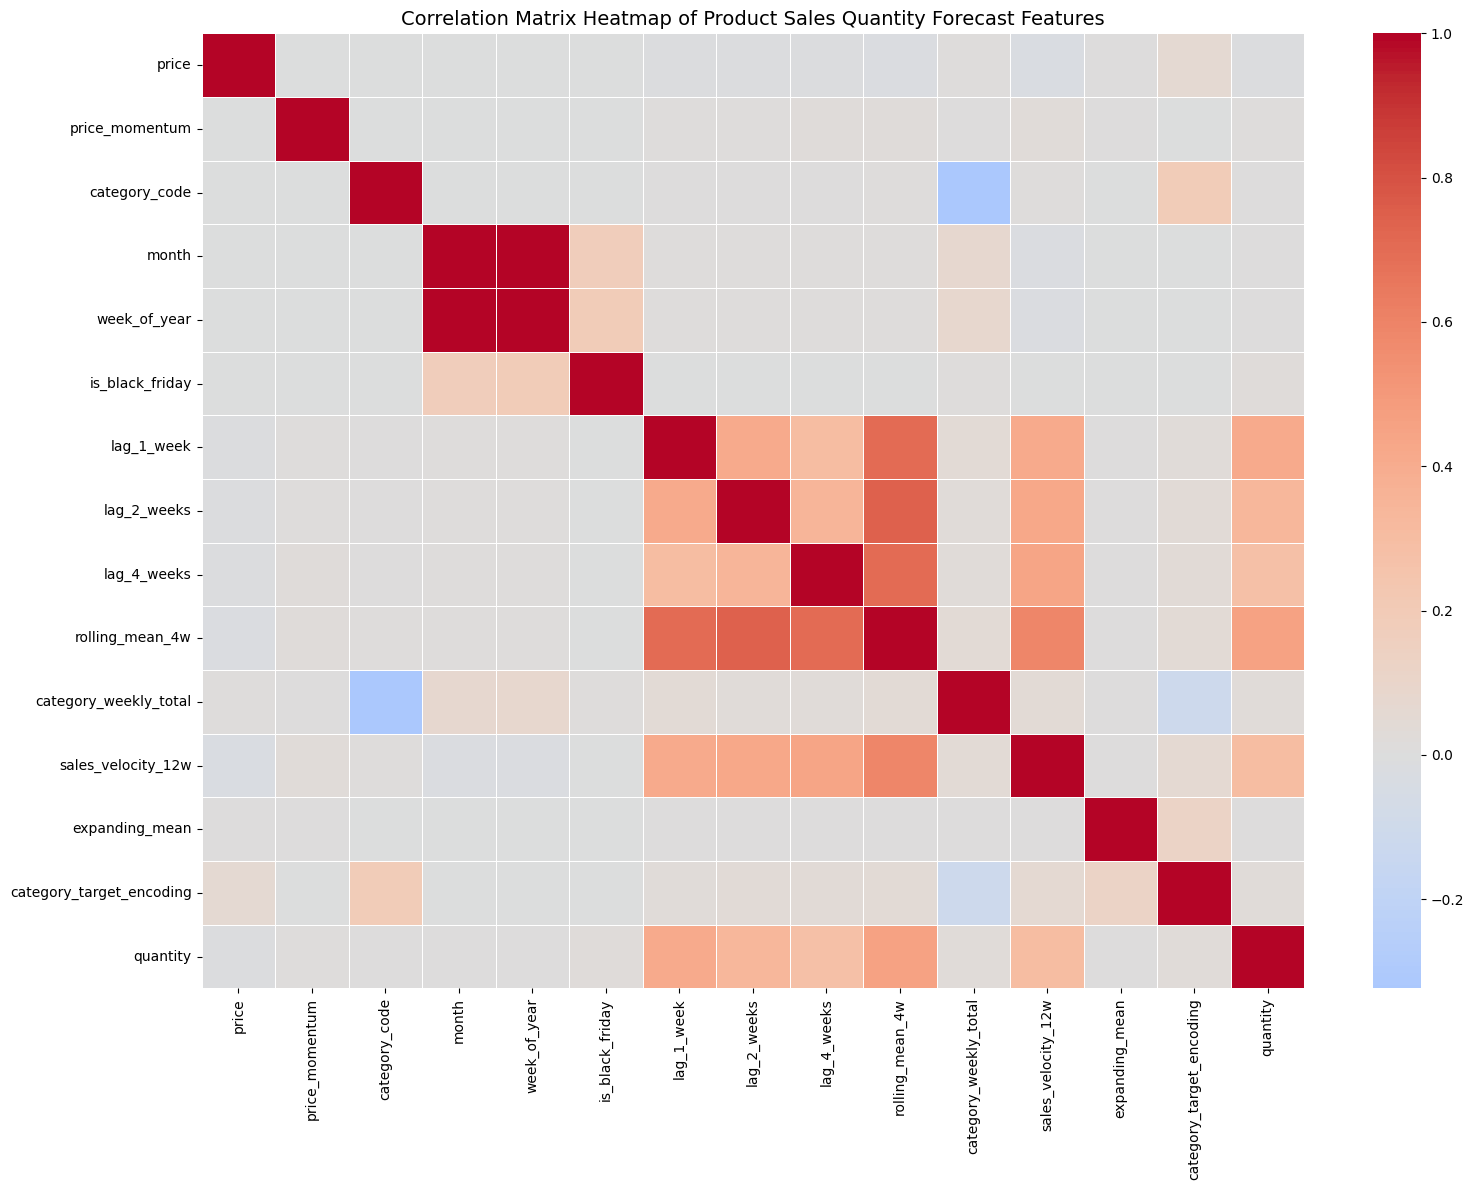

In [6]:
features = [
    'price',
    'price_momentum', 
    'category_code', 
    'month', 
    'week_of_year', 
    'is_black_friday',
    'lag_1_week', 
    'lag_2_weeks',
    'lag_4_weeks', 
    'rolling_mean_4w',
    'category_weekly_total',
    'sales_velocity_12w',
    'expanding_mean',
    'category_target_encoding'
]
target = 'quantity'
selected_cols = features + [target]

corr_df = product_sales_data[selected_cols]

corr_matrix = corr_df.corr(method='pearson')
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,     # set True only if you want numbers (can be cluttered)
    linewidths=0.5
)

plt.title('Correlation Matrix Heatmap of Product Sales Quantity Forecast Features', fontsize=14)
plt.tight_layout()
plt.show()

Data Splitting

In [7]:
# Split data (e.g., use data before 2018-06-01 for training)
split_date = '2018-06-01'

train = product_sales_data.loc[product_sales_data['order_purchase_timestamp'] < split_date]
test = product_sales_data.loc[product_sales_data['order_purchase_timestamp'] >= split_date]

print("Train set date range:")
print("Min:", train['order_purchase_timestamp'].min())
print("Max:", train['order_purchase_timestamp'].max())

print("\nTest set date range:")
print("Min:", test['order_purchase_timestamp'].min())
print("Max:", test['order_purchase_timestamp'].max())

Train set date range:
Min: 2017-02-05 00:00:00
Max: 2018-05-27 00:00:00

Test set date range:
Min: 2018-06-03 00:00:00
Max: 2018-08-26 00:00:00


Prepare X & Y train test

In [8]:
features = [
    'price',
    'price_momentum', 
    'category_code', 
    'month', 
    'week_of_year', 
    'is_black_friday',
    'lag_1_week', 
    'lag_2_weeks',
    'lag_4_weeks', 
    'rolling_mean_4w',
    'category_weekly_total',
    'sales_velocity_12w',
    'expanding_mean',
    'category_target_encoding'
]
target = 'quantity'

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

Business Value Performance Evaluation

In [9]:
def calculate_business_metrics(y_true, y_pred):
    results = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
    
    # 1. Global Bias (Volume Accuracy)
    total_actual = results['Actual'].sum()
    total_pred = results['Predicted'].sum()
    bias = total_pred / total_actual
    
    # 2. Weighted MAPE (Volume Error %)
    # Sum of Absolute Errors / Sum of Actuals
    wmape = np.sum(np.abs(results['Actual'] - results['Predicted'])) / total_actual * 100
    
    # 3. Active MAE (Accuracy on non-zero weeks)
    active_rows = results[results['Actual'] > 0]
    active_mae = np.mean(np.abs(active_rows['Actual'] - active_rows['Predicted']))
    
    # 4. Service Level (Estimated Fulfill Rate)
    # If Actual > Pred, we missed (Actual - Pred) sales.
    # If Actual <= Pred, we missed 0.
    missed_sales = np.sum(np.maximum(results['Actual'] - np.ceil(results['Predicted']), 0))
    service_level = 1 - (missed_sales / total_actual)
    
    return {
        "Global Bias (Target: 0.90-1.10)": round(bias, 4),
        "wMAPE (Weighted Error %)": f"{round(wmape, 2)}%",
        "Active MAE (Error on Active Weeks)": round(active_mae, 4),
        "Service Level (Fulfillment Rate)": f"{round(service_level * 100, 2)}%"
    }

**Linear Regression**

In [10]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model Evaluation

Linear Regression - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0849  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3206  |
+------------------------------------+---------+
| R² Score                           | 0.1308  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.9626  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 162.59% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.1563  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 77.23%  |
+------------------------------------+---------+


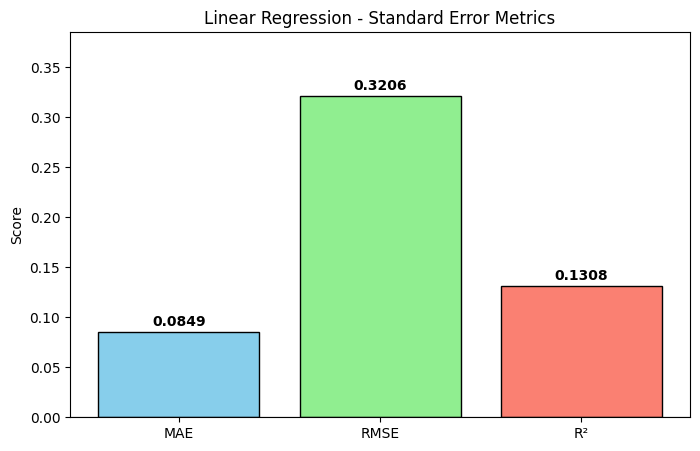

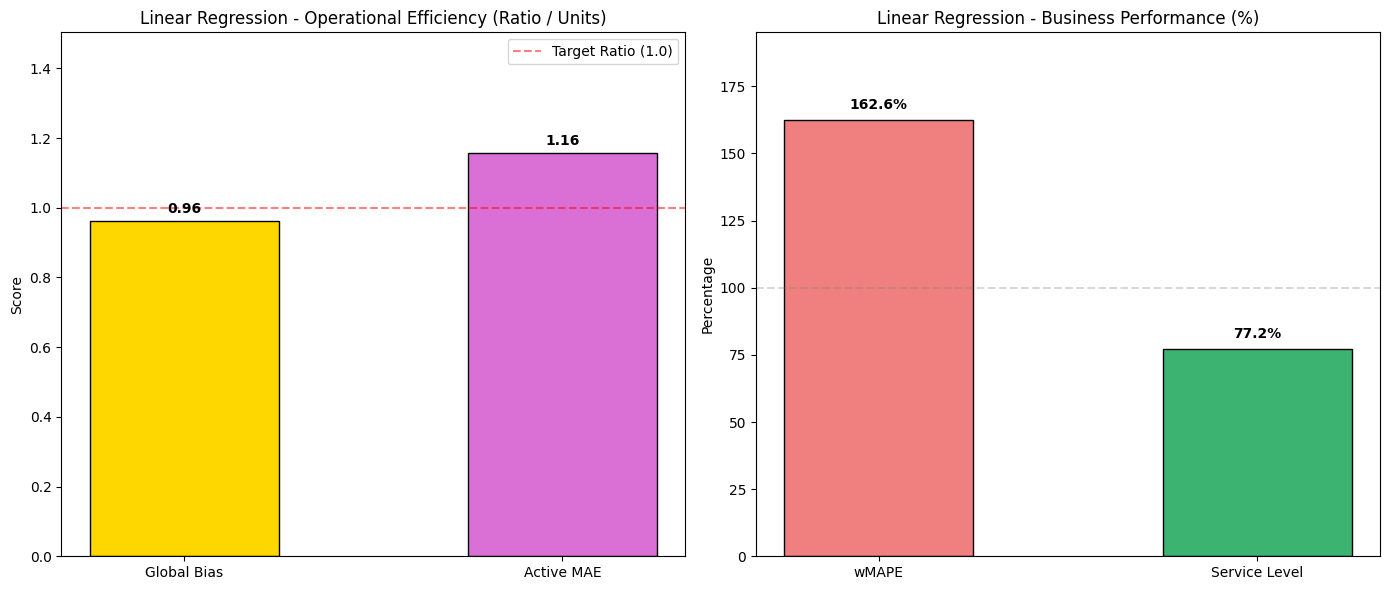

In [11]:
y_pred_clipped = np.maximum(y_pred, 0) 

lr_mae = mean_absolute_error(y_test, y_pred_clipped)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_clipped))
lr_r2 = r2_score(y_test, y_pred_clipped)

lr_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{lr_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{lr_rmse:.4f}"],
    ["R² Score", f"{lr_r2:.4f}"]
]

for metric_name, score in lr_bus_metrics.items():
    eval_table.append([metric_name, score])

print("Linear Regression - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [lr_mae, lr_rmse, lr_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Linear Regression - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in lr_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("Linear Regression - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("Linear Regression - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Random Forest**

In [18]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Model Evaluation

Random Forest - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0765  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3126  |
+------------------------------------+---------+
| R² Score                           | 0.1735  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.9152  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 146.37% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.1043  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 79.05%  |
+------------------------------------+---------+


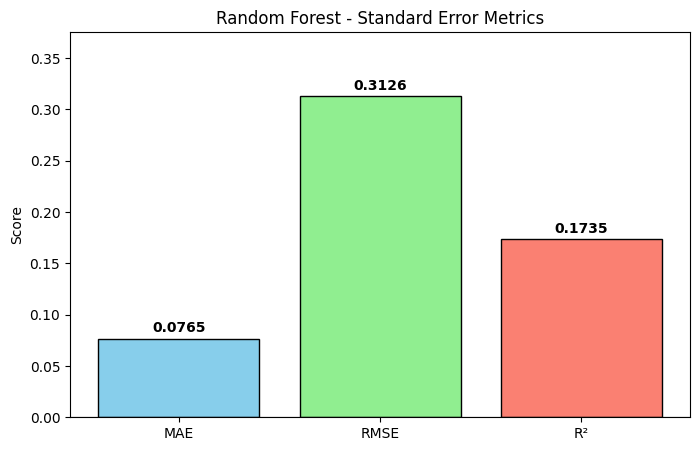

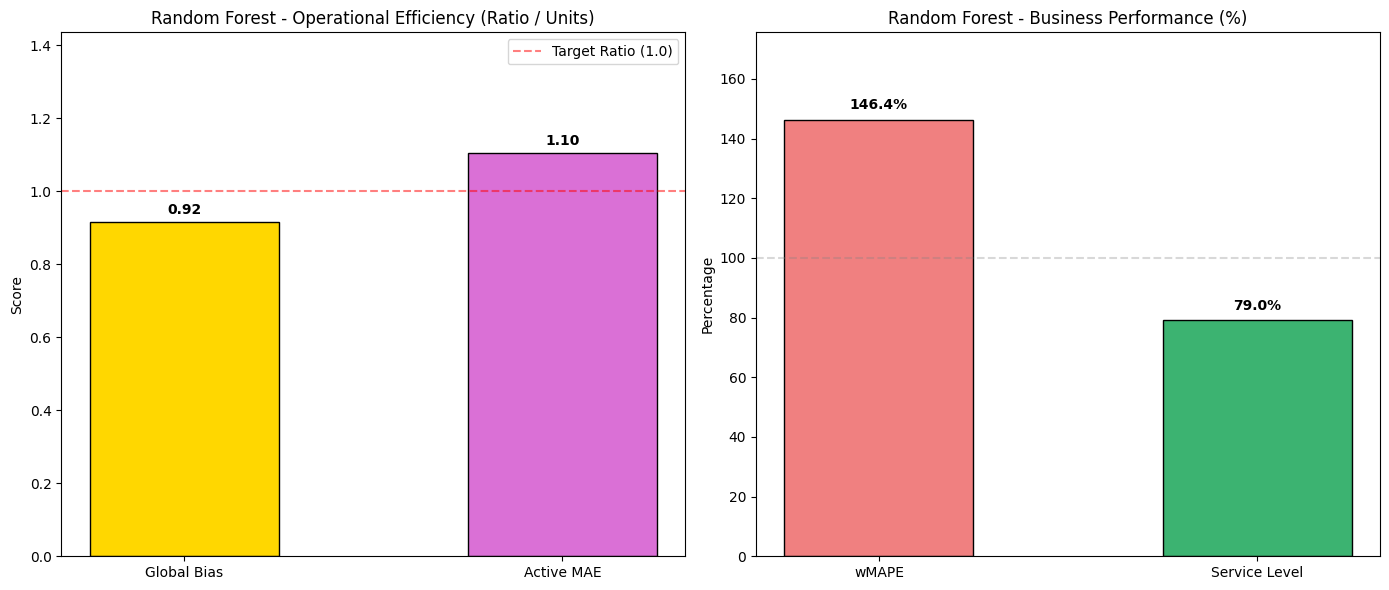

In [19]:
y_pred_clipped = np.maximum(rf_pred, 0) 

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

rf_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{rf_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{rf_rmse:.4f}"],
    ["R² Score", f"{rf_r2:.4f}"]
]

for metric_name, score in rf_bus_metrics.items():
    eval_table.append([metric_name, score])

print("Random Forest - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [rf_mae, rf_rmse, rf_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Random Forest - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in rf_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("Random Forest - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("Random Forest - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**XGBoost**

In [12]:
reg_xgb = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,objective='count:poisson', random_state=42)
reg_xgb.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

xgb_pred = reg_xgb.predict(X_test)

[0]	validation_0-poisson-nloglik:0.17652	validation_1-poisson-nloglik:0.21724
[76]	validation_0-poisson-nloglik:0.12961	validation_1-poisson-nloglik:0.17168


Model Evaluation

XGBoost - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0762  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3015  |
+------------------------------------+---------+
| R² Score                           | 0.2312  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.9184  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 145.91% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.0747  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 78.65%  |
+------------------------------------+---------+


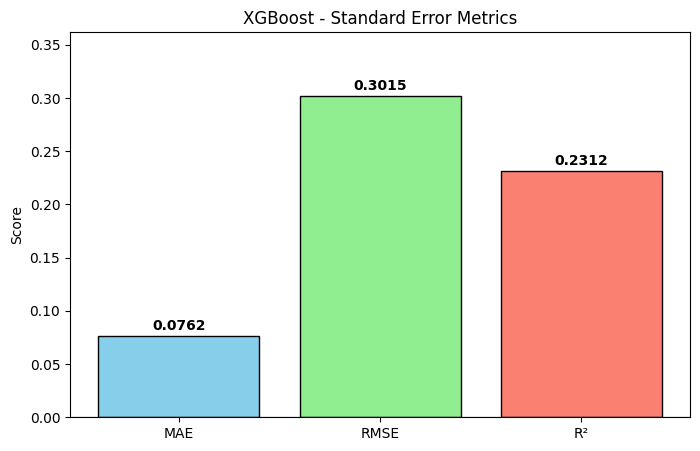

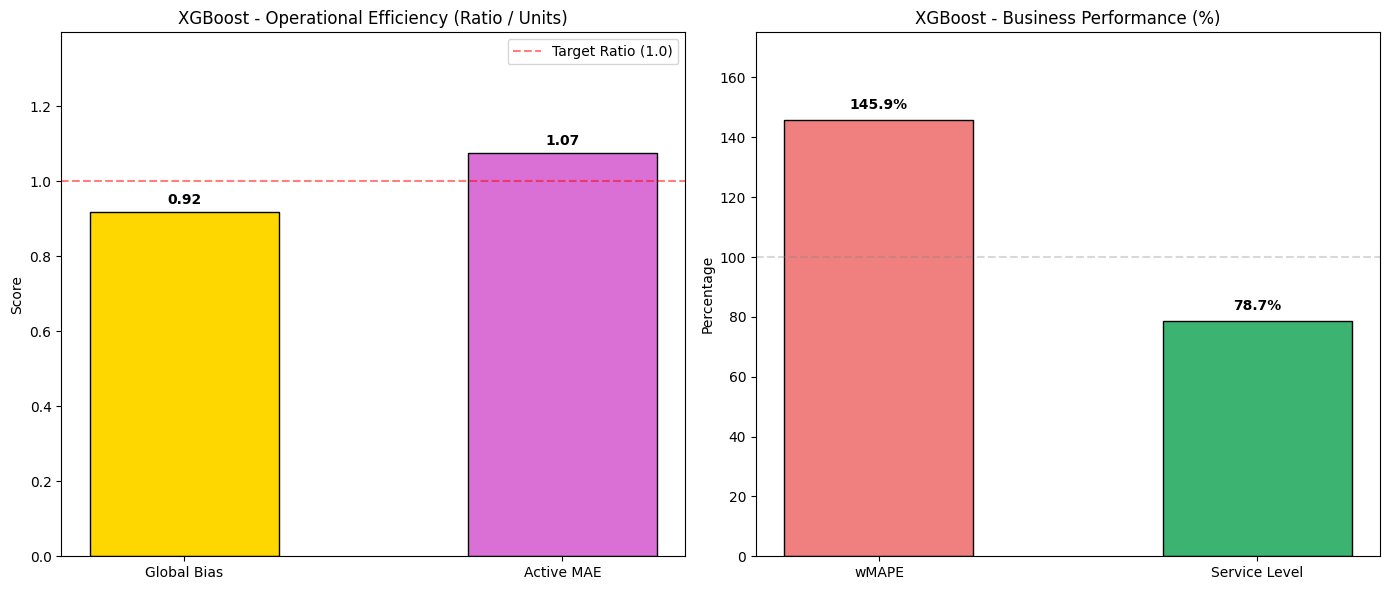

In [13]:
y_pred_clipped = np.maximum(xgb_pred, 0) 

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

xgb_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{xgb_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{xgb_rmse:.4f}"],
    ["R² Score", f"{xgb_r2:.4f}"]
]

for metric_name, score in xgb_bus_metrics.items():
    eval_table.append([metric_name, score])

print("XGBoost - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [xgb_mae, xgb_rmse, xgb_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("XGBoost - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in xgb_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("XGBoost - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("XGBoost - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**LightGBM**

In [21]:
cat_features = ['category_code', 'month', 'week_of_year', 'is_black_friday']

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_features)

params = {
    'objective': 'poisson',
    'metric': 'rmse',
    'learning_rate': 0.01, 
    'num_leaves': 15,      
    'min_child_samples': 50, 
    'reg_alpha': 1.0,      
    'reg_lambda': 1.0,     
    'verbose': -1
}

lgbm_model = lgb.train(
    params, 
    train_data, 
    num_boost_round=1000, 
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

lgbm_pred = lgbm_model.predict(X_test)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.318307
[200]	valid_0's rmse: 0.309093
[300]	valid_0's rmse: 0.30609
[400]	valid_0's rmse: 0.305481
Early stopping, best iteration is:
[403]	valid_0's rmse: 0.305478


Model Evaluation

LightGBM - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0763  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3055  |
+------------------------------------+---------+
| R² Score                           | 0.2107  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.8873  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 145.97% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.0924  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 77.7%   |
+------------------------------------+---------+


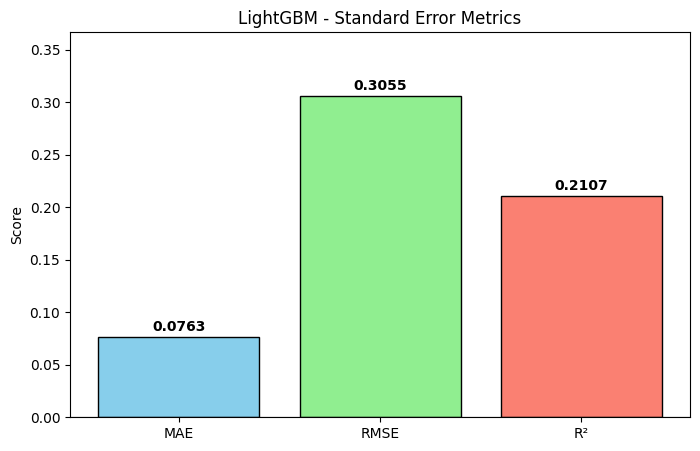

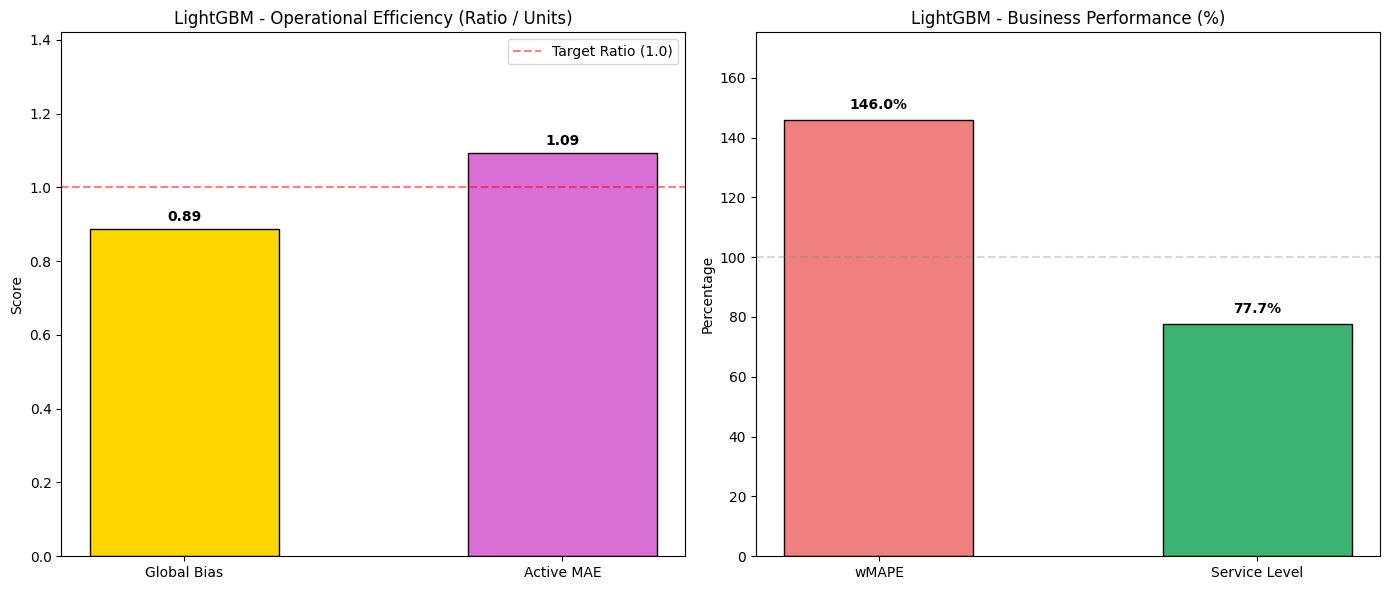

In [22]:
y_pred_clipped = np.maximum(lgbm_pred, 0) 

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2 = r2_score(y_test, lgbm_pred)

lgbm_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{lgbm_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{lgbm_rmse:.4f}"],
    ["R² Score", f"{lgbm_r2:.4f}"]
]

for metric_name, score in lgbm_bus_metrics.items():
    eval_table.append([metric_name, score])

print("LightGBM - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [lgbm_mae, lgbm_rmse, lgbm_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("LightGBM - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in lgbm_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("LightGBM - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("LightGBM - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning

**Time Series Split**

In [23]:
tscv = TimeSeriesSplit(n_splits=5)

**Linear Regression**

In [25]:
lr_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_search = GridSearchCV(
    estimator=LinearRegression(n_jobs=-1),
    param_grid=lr_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X_train, y_train)

print("Best LR parameters:", lr_search.best_params_)
print("Best LR Score (Negative RMSE):", lr_search.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR parameters: {'fit_intercept': False, 'positive': False}
Best LR Score (Negative RMSE): -0.2971966800302922


Model Evaluation

Tuned Linear Regression - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0850  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3206  |
+------------------------------------+---------+
| R² Score                           | 0.1308  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.9628  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 162.59% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.1562  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 77.74%  |
+------------------------------------+---------+


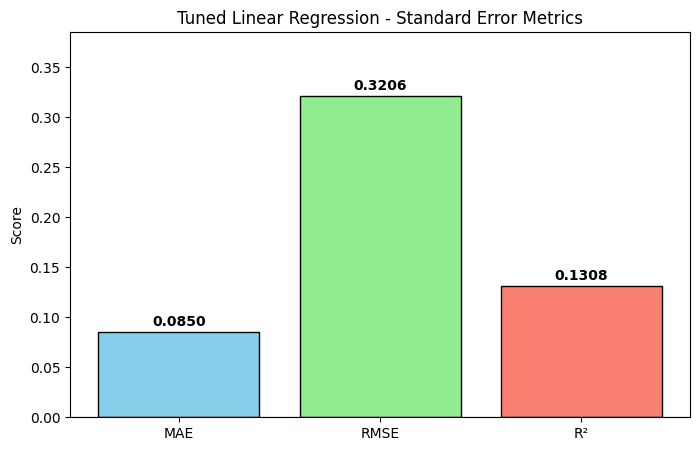

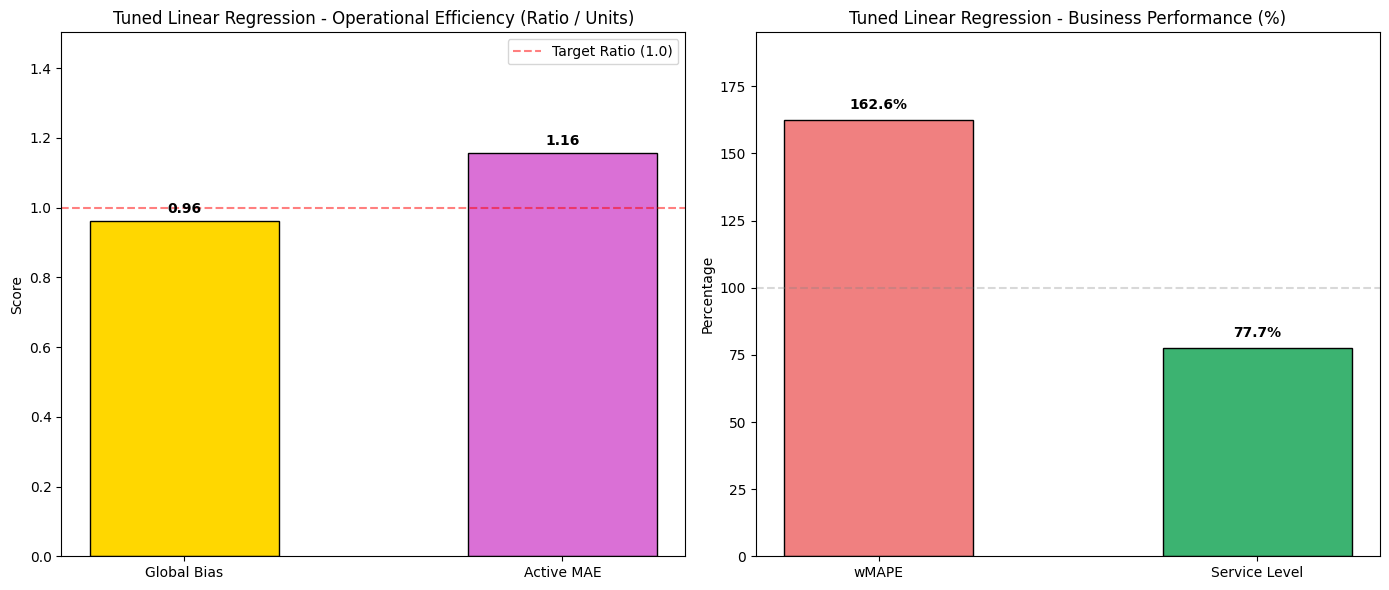

In [27]:
best_lr_model = lr_search.best_estimator_
best_lr_y_pred = best_lr_model.predict(X_test)

best_lr_mae = mean_absolute_error(y_test, best_lr_y_pred)
best_lr_rmse = np.sqrt(mean_squared_error(y_test, best_lr_y_pred))
best_lr_r2 = r2_score(y_test, best_lr_y_pred)

y_pred_clipped = np.maximum(best_lr_y_pred, 0) 

best_lr_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{best_lr_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{best_lr_rmse:.4f}"],
    ["R² Score", f"{best_lr_r2:.4f}"]
]

for metric_name, score in best_lr_bus_metrics.items():
    eval_table.append([metric_name, score])

print("Tuned Linear Regression - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [best_lr_mae, best_lr_rmse, best_lr_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned Linear Regression - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in best_lr_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("Tuned Linear Regression - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("Tuned Linear Regression - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Performance Comparison

In [28]:
def plot_model_comparison(metrics_names, base_scores, tuned_scores, title, ax):
    x = np.arange(len(metrics_names))
    width = 0.35
    
    rects1 = ax.bar(x - width/2, base_scores, width, label='Base Model', color='skyblue', edgecolor='black')
    rects2 = ax.bar(x + width/2, tuned_scores, width, label='Tuned Model', color='salmon', edgecolor='black')
    
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names)
    
    # Dynamic Y-Limit
    max_val = max(max(base_scores), max(tuned_scores))
    if max_val > 10: # Likely percentage
        ax.set_ylim(0, max(110, max_val * 1.2))
    else: # Likely decimals
        ax.set_ylim(min(min(base_scores), 0) * 1.2, max_val * 1.3)
        
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Helper to label bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    autolabel(rects1)
    autolabel(rects2)

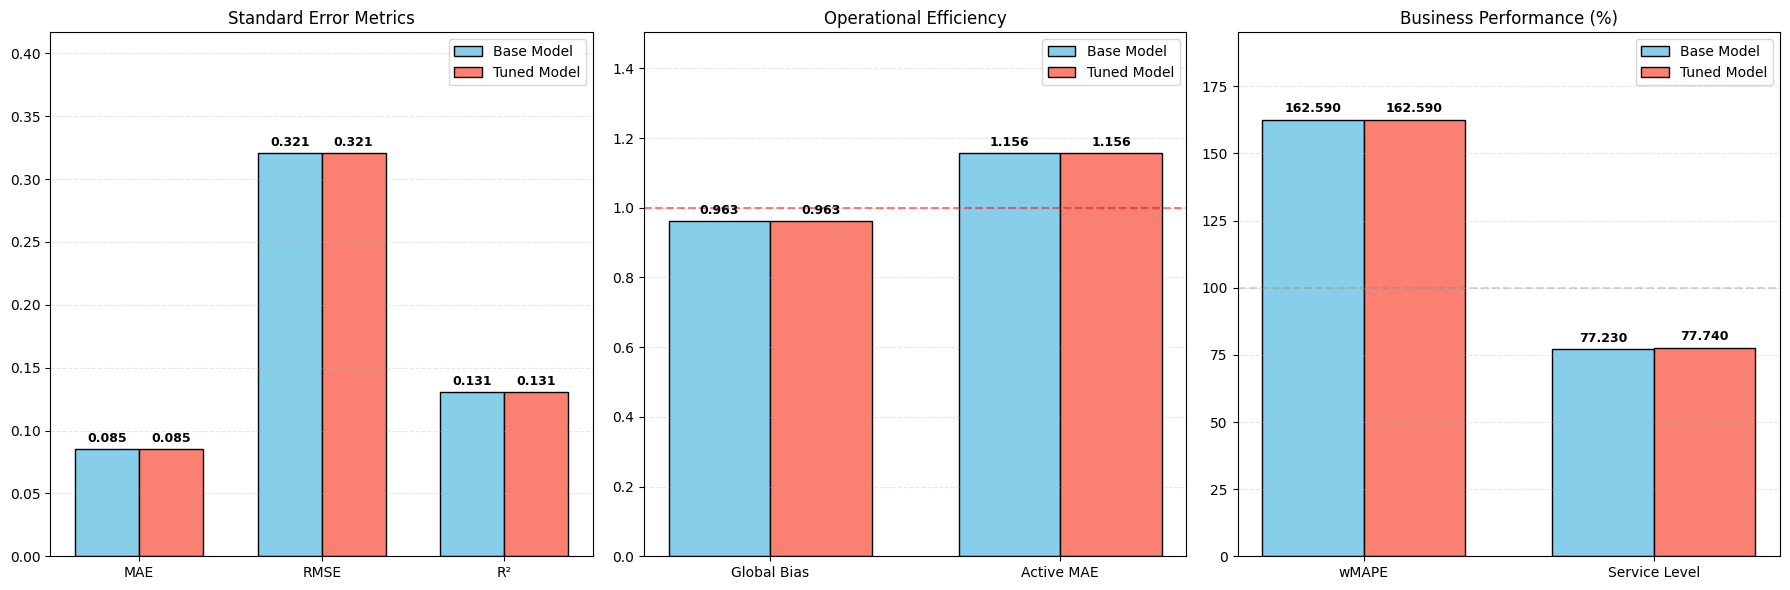

In [ ]:
std_metrics = ["MAE", "RMSE", "R²"]
base_std = [lr_mae, lr_rmse, lr_r2]
tuned_std = [best_lr_mae, best_lr_rmse, best_lr_r2]

def get_val(metrics_dict, key):
    val = metrics_dict[key]
    return float(val.strip('%')) if isinstance(val, str) else val

op_metrics = ["Global Bias", "Active MAE"]
base_op = [get_val(lr_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]
tuned_op = [get_val(best_lr_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]

biz_metrics = ["wMAPE", "Service Level"]
base_biz = [get_val(lr_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]
tuned_biz = [get_val(best_lr_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_model_comparison(std_metrics, base_std, tuned_std, "Linear Regression - Standard Error Metrics", axes[0])
plot_model_comparison(op_metrics, base_op, tuned_op, "Linear Regression - Operational Efficiency", axes[1])
plot_model_comparison(biz_metrics, base_biz, tuned_biz, "Linear Regression - Business Performance (%)", axes[2])

# Add Target Lines for context
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target (1.0)')
axes[2].axhline(100, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Random Forest**

In [11]:
rf_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [5, 10, 15, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2', 0.5, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_grid,
    n_iter=30, 
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)

# 3. Fit
print("Tuning Random Forest...")
rf_search.fit(X_train, y_train)

print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF Score (Negative RMSE): {rf_search.best_score_}")

Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10}
Best RF Score (Negative RMSE): -0.2888069287725801


Model Evaluation

Tuned Random Forest - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0760  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3069  |
+------------------------------------+---------+
| R² Score                           | 0.2032  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.9366  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 145.42% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.0821  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 79.61%  |
+------------------------------------+---------+


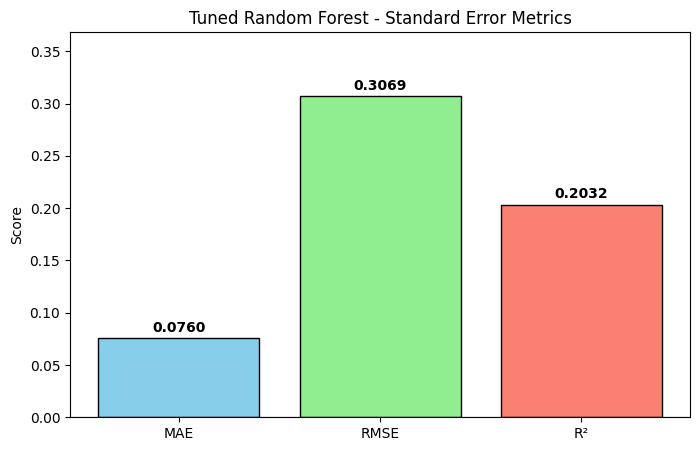

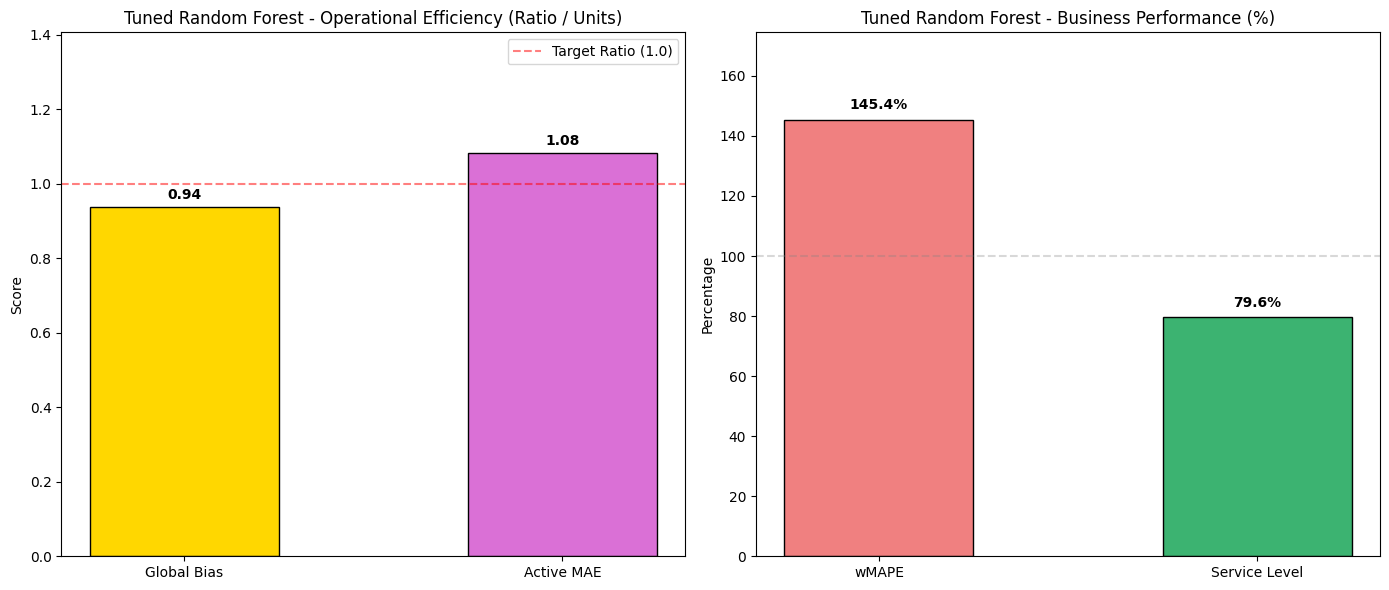

In [ ]:
best_rf_model = rf_search.best_estimator_
best_rf_y_pred = best_rf_model.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_y_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_y_pred))
best_rf_r2 = r2_score(y_test, best_rf_y_pred)

y_pred_clipped = np.maximum(best_rf_y_pred, 0) 

best_rf_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{best_rf_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{best_rf_rmse:.4f}"],
    ["R² Score", f"{best_rf_r2:.4f}"]
]

for metric_name, score in best_rf_bus_metrics.items():
    eval_table.append([metric_name, score])

print("Tuned Random Forest - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [best_rf_mae, best_rf_rmse, best_rf_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned Random Forest - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in best_rf_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("Tuned Random Forest - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("Tuned Random Forest - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Performance Comparison

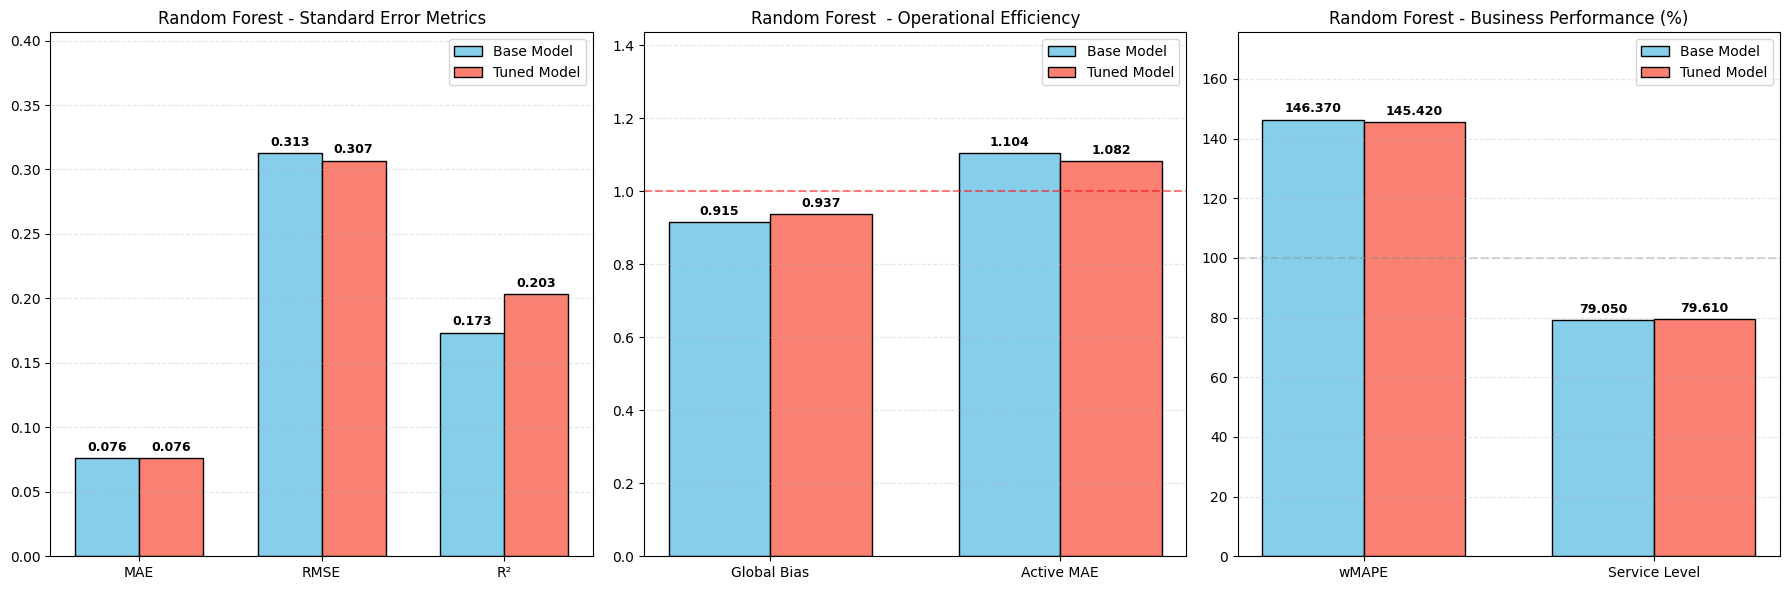

In [36]:
std_metrics = ["MAE", "RMSE", "R²"]
base_std = [rf_mae, rf_rmse, rf_r2]
tuned_std = [best_rf_mae, best_rf_rmse, best_rf_r2]

def get_val(metrics_dict, key):
    val = metrics_dict[key]
    return float(val.strip('%')) if isinstance(val, str) else val

op_metrics = ["Global Bias", "Active MAE"]
base_op = [get_val(rf_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]
tuned_op = [get_val(best_rf_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]

biz_metrics = ["wMAPE", "Service Level"]
base_biz = [get_val(rf_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]
tuned_biz = [get_val(best_rf_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_model_comparison(std_metrics, base_std, tuned_std, "Random Forest - Standard Error Metrics", axes[0])
plot_model_comparison(op_metrics, base_op, tuned_op, "Random Forest  - Operational Efficiency", axes[1])
plot_model_comparison(biz_metrics, base_biz, tuned_biz, "Random Forest - Business Performance (%)", axes[2])

# Add Target Lines for context
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target (1.0)')
axes[2].axhline(100, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**XGBoost**

In [24]:
xgb_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_lambda': [0.1, 1.0, 10.0],
    'reg_alpha': [0.0, 0.1, 1.0]
}

# 2. Setup Search
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='count:poisson', random_state=42, n_jobs=-1),
    param_distributions=xgb_grid,
    n_iter=30,
    cv=tscv,
    random_state=42,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 3. Fit
print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)

print(f"Best XGB Params: {xgb_search.best_params_}")
print(f"Best XGB Score (Negative RMSE): {xgb_search.best_score_}")

Tuning XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB Params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best XGB Score (Negative RMSE): -0.29697640538215636


Train With Best Parameter

In [ ]:
best_params = xgb_search.best_params_
final_model = xgb.XGBRegressor(
    **best_params,
    early_stopping_rounds=50,
    objective='count:poisson',
    random_state=42
)

final_model.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

best_xgb_y_pred = final_model.predict(X_test)

[0]	validation_0-poisson-nloglik:0.18085	validation_1-poisson-nloglik:0.22193
[100]	validation_0-poisson-nloglik:0.13762	validation_1-poisson-nloglik:0.17440
[200]	validation_0-poisson-nloglik:0.13302	validation_1-poisson-nloglik:0.17198
[278]	validation_0-poisson-nloglik:0.13245	validation_1-poisson-nloglik:0.17195


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned XGBoost - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0774  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3048  |
+------------------------------------+---------+
| R² Score                           | 0.2142  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.9264  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 148.19% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.0886  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 78.54%  |
+------------------------------------+---------+


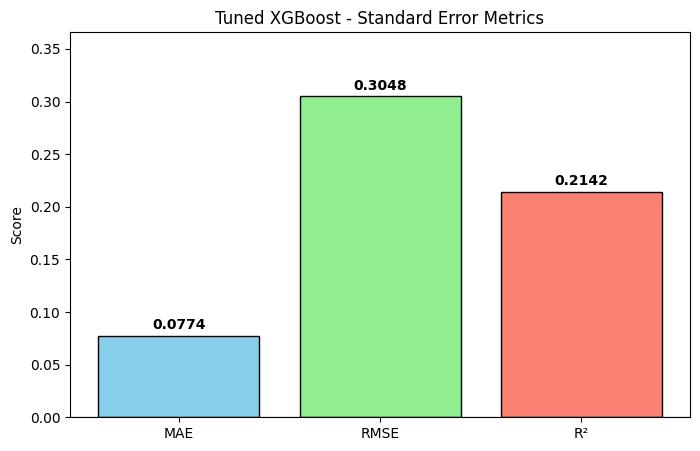

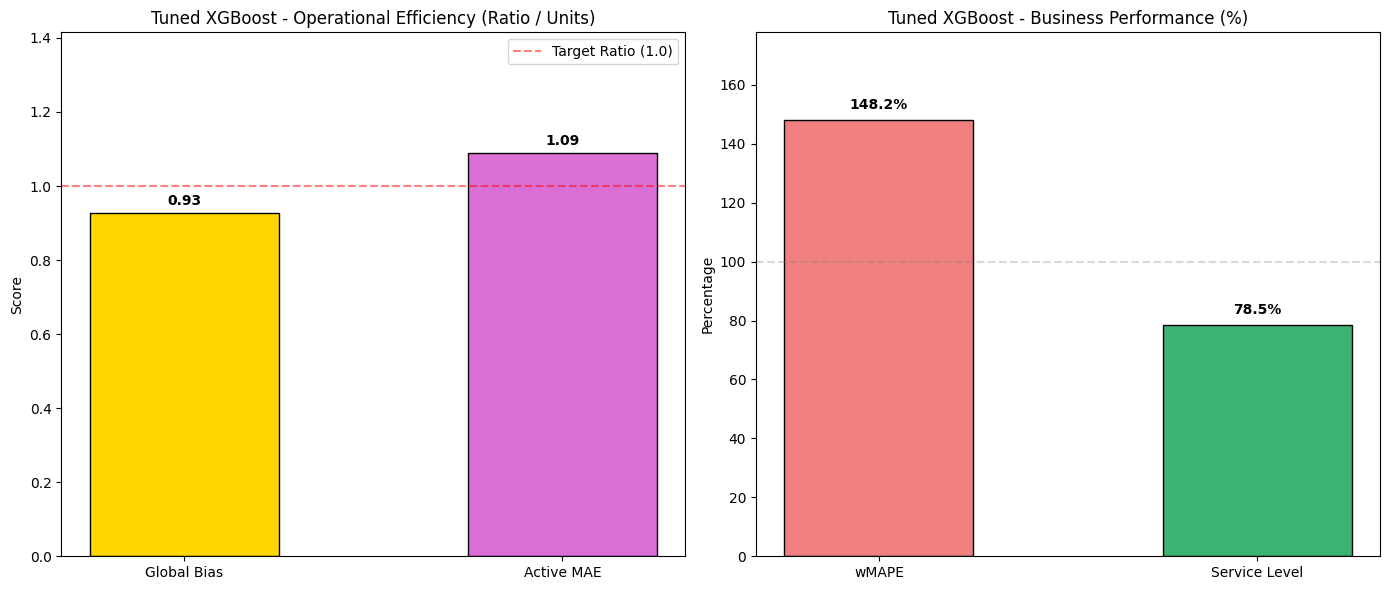

In [11]:
best_xgb_mae = mean_absolute_error(y_test, best_xgb_y_pred)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test, best_xgb_y_pred))
best_xgb_r2 = r2_score(y_test, best_xgb_y_pred)

y_pred_clipped = np.maximum(best_xgb_y_pred, 0) 

best_xgb_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{best_xgb_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{best_xgb_rmse:.4f}"],
    ["R² Score", f"{best_xgb_r2:.4f}"]
]

for metric_name, score in best_xgb_bus_metrics.items():
    eval_table.append([metric_name, score])

print("Tuned XGBoost - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [best_xgb_mae, best_xgb_rmse, best_xgb_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned XGBoost - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in best_xgb_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("Tuned XGBoost - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("Tuned XGBoost - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Performance Comparison

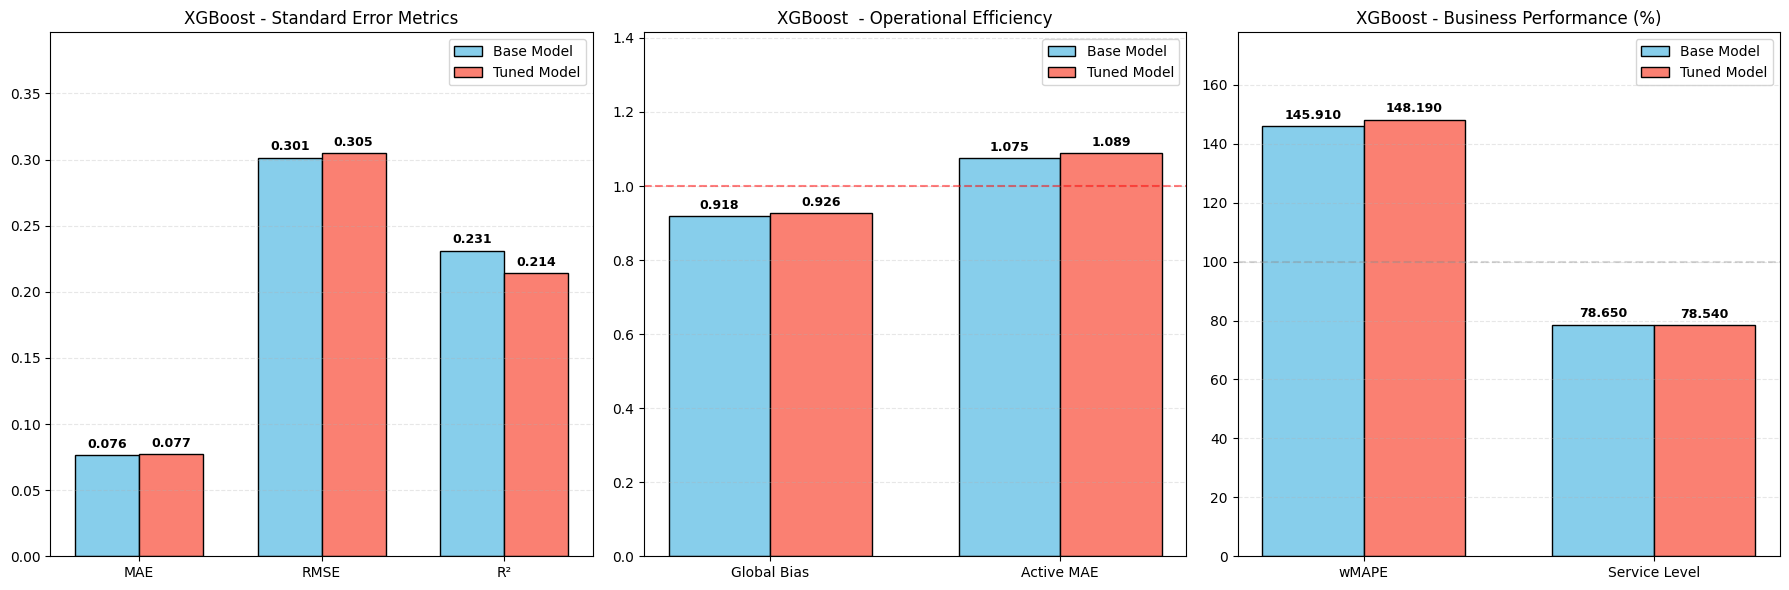

In [43]:
std_metrics = ["MAE", "RMSE", "R²"]
base_std = [xgb_mae, xgb_rmse, xgb_r2]
tuned_std = [best_xgb_mae, best_xgb_rmse, best_xgb_r2]

def get_val(metrics_dict, key):
    val = metrics_dict[key]
    return float(val.strip('%')) if isinstance(val, str) else val

op_metrics = ["Global Bias", "Active MAE"]
base_op = [get_val(xgb_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]
tuned_op = [get_val(best_xgb_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]

biz_metrics = ["wMAPE", "Service Level"]
base_biz = [get_val(xgb_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]
tuned_biz = [get_val(best_xgb_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_model_comparison(std_metrics, base_std, tuned_std, "XGBoost - Standard Error Metrics", axes[0])
plot_model_comparison(op_metrics, base_op, tuned_op, "XGBoost  - Operational Efficiency", axes[1])
plot_model_comparison(biz_metrics, base_biz, tuned_biz, "XGBoost - Business Performance (%)", axes[2])

# Add Target Lines for context
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target (1.0)')
axes[2].axhline(100, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**LightGBM**

In [33]:
cat_cols = ['category_code', 'month', 'week_of_year', 'is_black_friday']
X_train_lgb = X_train.copy()
for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')

static_params = {
    'objective': 'poisson',
    'metric': 'rmse',
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgb_grid = {
    'n_estimators': [500, 1000, 1500],
    'num_leaves': [15, 31, 63],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [20, 50, 100],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.0, 0.1, 1.0, 5.0], 
    'reg_lambda': [0.0, 1.0, 5.0, 10.0]
}

# 2. Setup Search
lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(**static_params),
    param_distributions=lgb_grid,
    n_iter=30,
    cv=tscv,
    random_state= 42,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 3. Fit
print("Tuning LightGBM...")
lgb_search.fit(X_train_lgb, y_train)

print(f"Best LightGBM Params: {lgb_search.best_params_}")
print(f"Best LightGBM Score (Negative RMSE): {lgb_search.best_score_}")

Tuning LightGBM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best LightGBM Params: {'reg_lambda': 10.0, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 1000, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best LightGBM Score (Negative RMSE): -0.28833991616399623


Train With Best Parameter

In [ ]:
tuned_params = lgb_search.best_params_
final_params = {**static_params, **tuned_params}

cat_features = ['category_code', 'month', 'week_of_year', 'is_black_friday']

train_data = lgb.Dataset(X_train, label=y_train, params=final_params,  categorical_feature=cat_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, params=final_params,  categorical_feature=cat_features)

num_rounds = final_params.pop('n_estimators', 1000)

final_lgbm_model = lgb.train(final_params, train_data, num_boost_round=num_rounds, 
                       valid_sets=[test_data],
                       callbacks=[lgb.early_stopping(stopping_rounds=50)])

best_lgbm_y_pred = final_lgbm_model.predict(X_test)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[456]	valid_0's rmse: 0.304522


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned LightGBM - Full Evaluation Report:
+------------------------------------+---------+
| Metric                             | Score   |
+====================================+=========+
| Mean Absolute Error (MAE)          | 0.0757  |
+------------------------------------+---------+
| Root Mean Squared Error (RMSE)     | 0.3045  |
+------------------------------------+---------+
| R² Score                           | 0.2156  |
+------------------------------------+---------+
| Global Bias (Target: 0.90-1.10)    | 0.8846  |
+------------------------------------+---------+
| wMAPE (Weighted Error %)           | 144.97% |
+------------------------------------+---------+
| Active MAE (Error on Active Weeks) | 1.0905  |
+------------------------------------+---------+
| Service Level (Fulfillment Rate)   | 78.04%  |
+------------------------------------+---------+


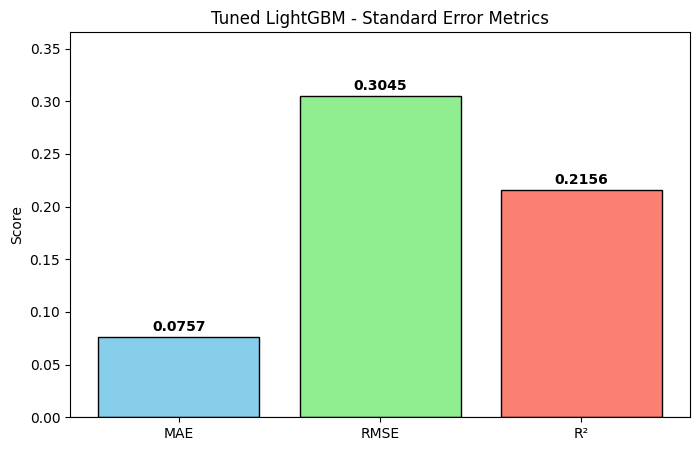

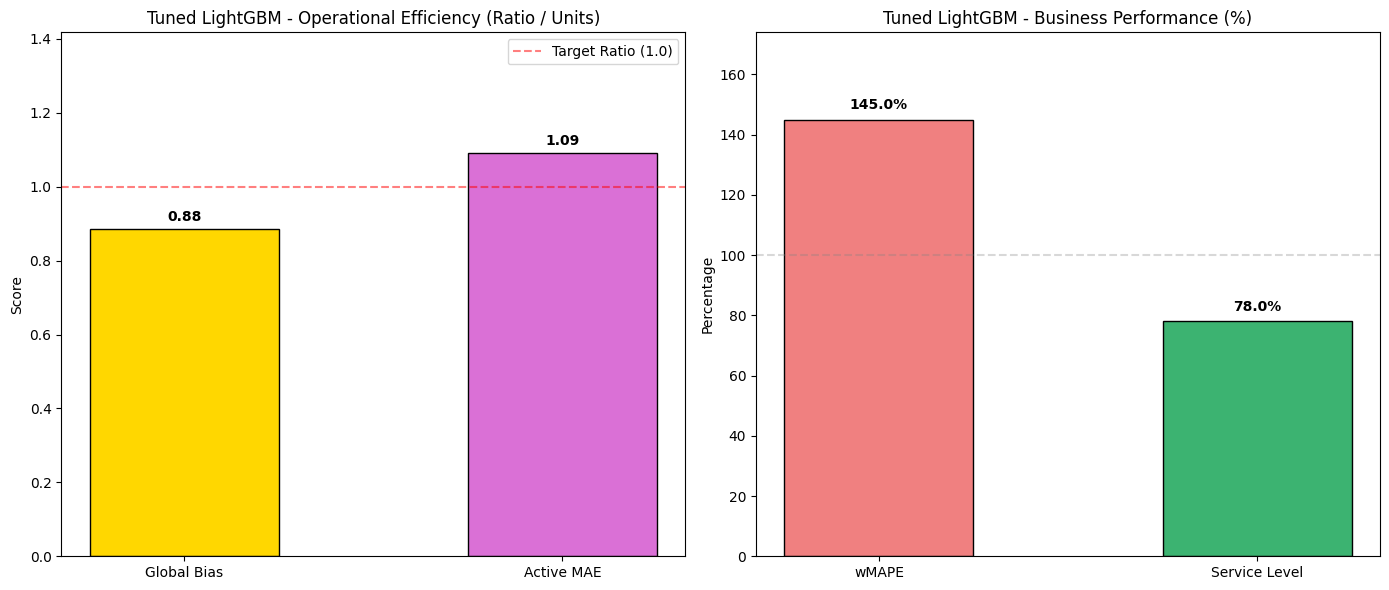

In [44]:
best_lgbm_mae = mean_absolute_error(y_test, best_lgbm_y_pred)
best_lgbm_rmse = np.sqrt(mean_squared_error(y_test, best_lgbm_y_pred))
best_lgbm_r2 = r2_score(y_test, best_lgbm_y_pred)

y_pred_clipped = np.maximum(best_lgbm_y_pred, 0) 

best_lgbm_bus_metrics = calculate_business_metrics(y_test, y_pred_clipped)

eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", f"{best_lgbm_mae:.4f}"],
    ["Root Mean Squared Error (RMSE)", f"{best_lgbm_rmse:.4f}"],
    ["R² Score", f"{best_lgbm_r2:.4f}"]
]

for metric_name, score in best_lgbm_bus_metrics.items():
    eval_table.append([metric_name, score])

print("Tuned LightGBM - Full Evaluation Report:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

metrics = ["MAE", "RMSE", "R²"]
scores = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_r2]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned LightGBM - Standard Error Metrics")
plt.ylabel("Score")

y_limit = max(scores) if max(scores) > 0 else 1.0
plt.ylim(min(scores)*1.2 if min(scores) < 0 else 0, y_limit * 1.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (y_limit * 0.02), 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8)
plt.show()

metrics_ratio = {}
metrics_pct = {}

for k, v in best_lgbm_bus_metrics.items():
    if "%" in str(v):
        metrics_pct[k.split(' (')[0]] = float(v.strip('%'))
    else:
        metrics_ratio[k.split(' (')[0]] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

names_1 = list(metrics_ratio.keys())
values_1 = list(metrics_ratio.values())
bars1 = ax1.bar(names_1, values_1, color=['gold', 'orchid'], edgecolor='black', width=0.5)

ax1.set_title("Tuned LightGBM - Operational Efficiency (Ratio / Units)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, max(values_1) * 1.3)
ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target Ratio (1.0)')
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + (max(values_1) * 0.02), 
             f"{height:.2f}", ha='center', fontweight='bold')

names_2 = list(metrics_pct.keys())
values_2 = list(metrics_pct.values())
bars2 = ax2.bar(names_2, values_2, color=['lightcoral', 'mediumseagreen'], edgecolor='black', width=0.5)

ax2.set_title("Tuned LightGBM - Business Performance (%)")
ax2.set_ylabel("Percentage")

max_pct = max(values_2)
y_limit_pct = max(110, max_pct * 1.2)
ax2.set_ylim(0, y_limit_pct)

ax2.axhline(100, color='gray', linestyle='--', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + (y_limit_pct * 0.02), 
             f"{height:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Performance Comparison

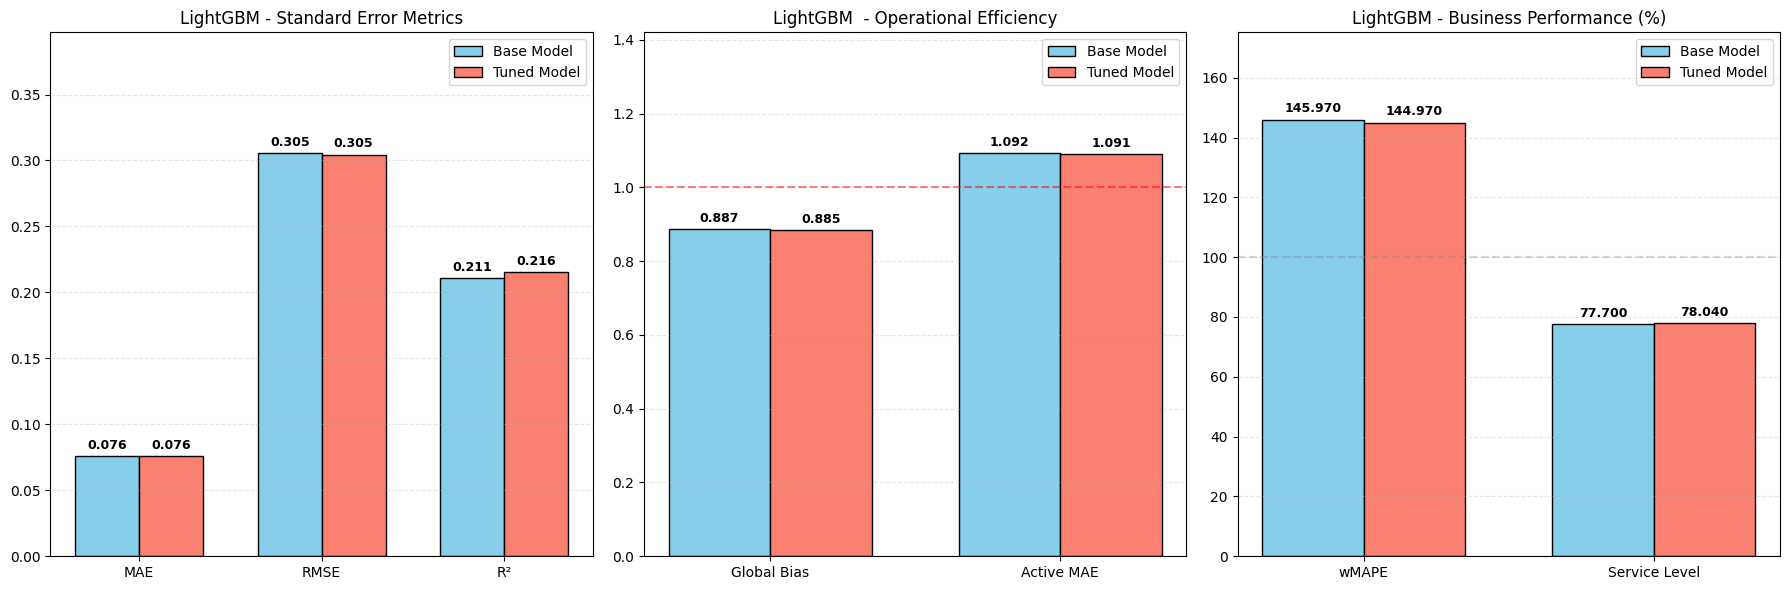

In [45]:
std_metrics = ["MAE", "RMSE", "R²"]
base_std = [lgbm_mae, lgbm_rmse, lgbm_r2]
tuned_std = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_r2]

def get_val(metrics_dict, key):
    val = metrics_dict[key]
    return float(val.strip('%')) if isinstance(val, str) else val

op_metrics = ["Global Bias", "Active MAE"]
base_op = [get_val(lgbm_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]
tuned_op = [get_val(best_lgbm_bus_metrics, k) for k in ["Global Bias (Target: 0.90-1.10)", "Active MAE (Error on Active Weeks)"]]

biz_metrics = ["wMAPE", "Service Level"]
base_biz = [get_val(lgbm_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]
tuned_biz = [get_val(best_lgbm_bus_metrics, k) for k in ["wMAPE (Weighted Error %)", "Service Level (Fulfillment Rate)"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_model_comparison(std_metrics, base_std, tuned_std, "LightGBM - Standard Error Metrics", axes[0])
plot_model_comparison(op_metrics, base_op, tuned_op, "LightGBM  - Operational Efficiency", axes[1])
plot_model_comparison(biz_metrics, base_biz, tuned_biz, "LightGBM - Business Performance (%)", axes[2])

# Add Target Lines for context
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Target (1.0)')
axes[2].axhline(100, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Best Model Performance Comparison Chart**

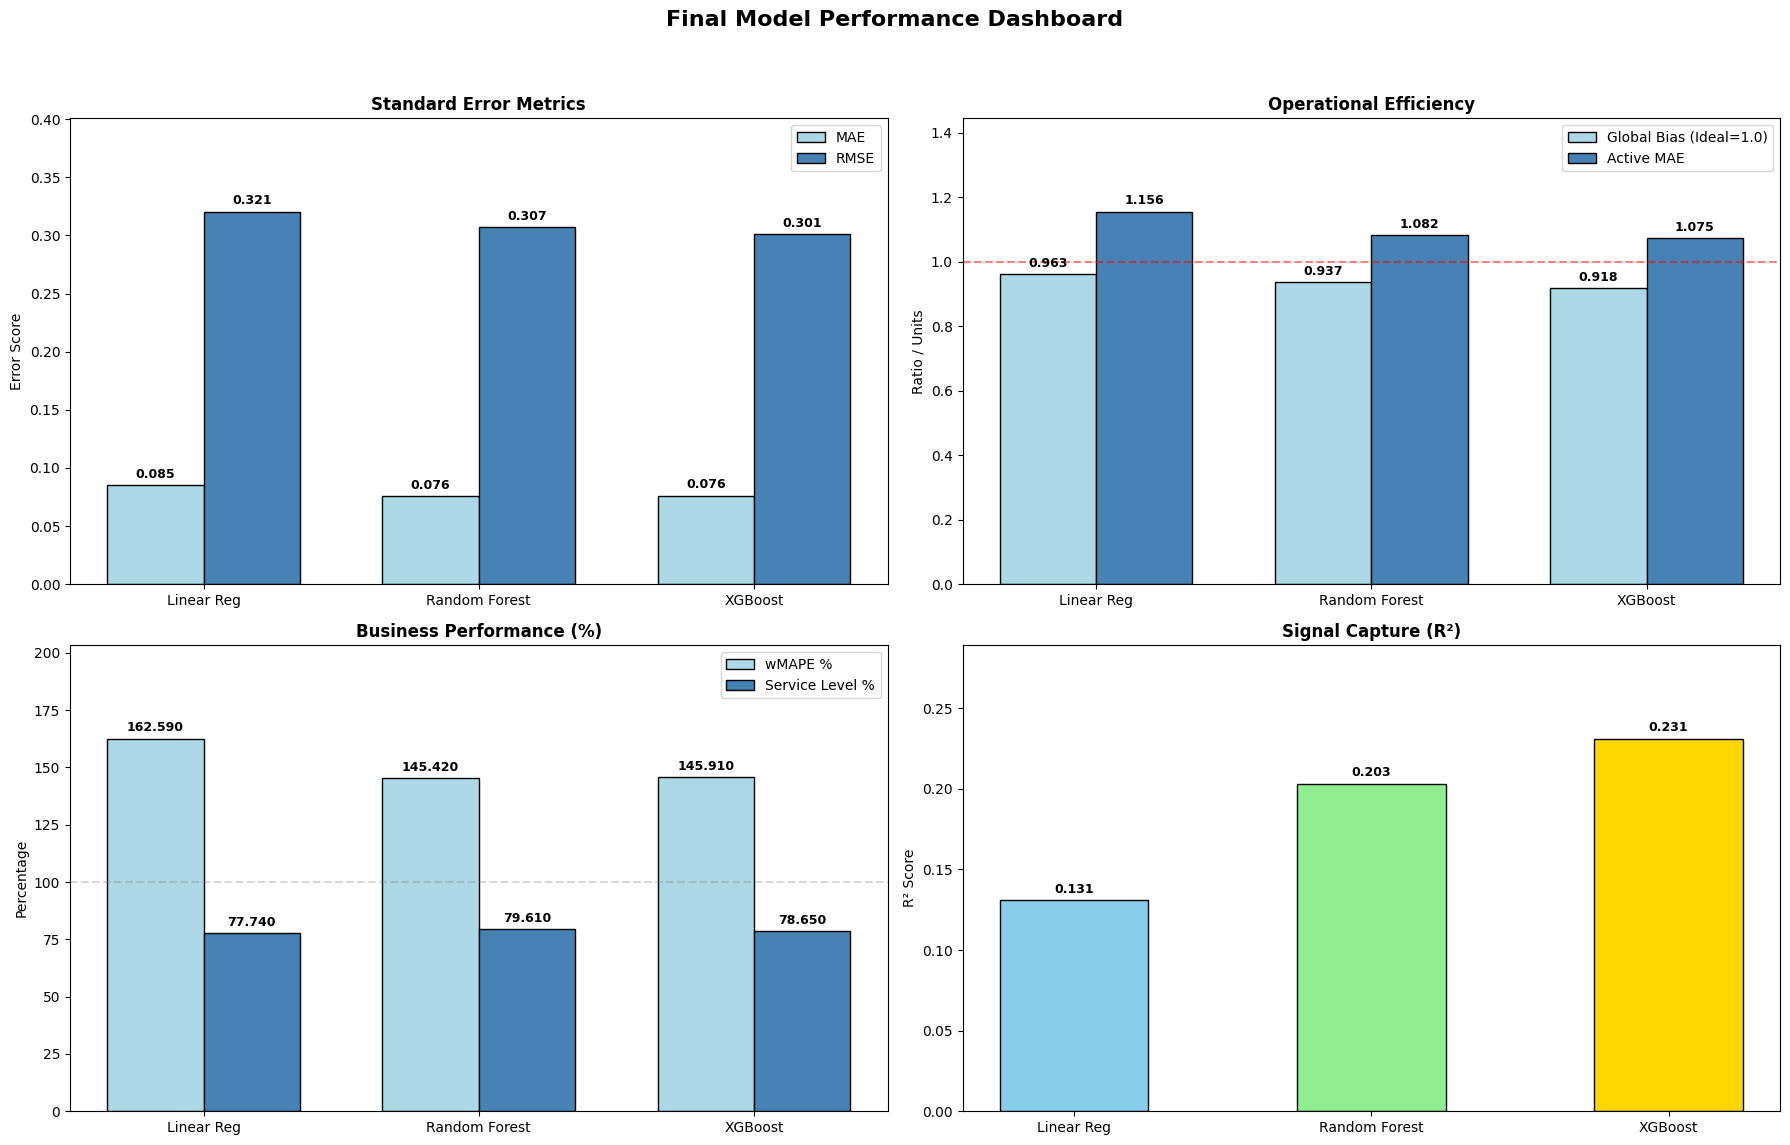

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SETUP DATA ---
models = ['Linear Reg', 'Random Forest', 'XGBoost']
colors = ['skyblue', 'lightgreen', 'gold']

# Standard Metrics
mae_scores  = [best_lr_mae, best_rf_mae, xgb_mae]
rmse_scores = [best_lr_rmse, best_rf_rmse, xgb_rmse]
r2_scores   = [best_lr_r2, best_rf_r2, xgb_r2]

# Helper to extract numbers from your metric dictionaries
def get_val(metrics_dict, key):
    val = metrics_dict[key]
    return float(val.strip('%')) if isinstance(val, str) else val

# Operational Metrics (Bias + Active MAE)
bias_scores = [get_val(m, "Global Bias (Target: 0.90-1.10)") for m in [best_lr_bus_metrics, best_rf_bus_metrics, xgb_bus_metrics]]
active_mae_scores = [get_val(m, "Active MAE (Error on Active Weeks)") for m in [best_lr_bus_metrics, best_rf_bus_metrics, xgb_bus_metrics]]

# Business Metrics (wMAPE + Service Level)
wmape_scores = [get_val(m, "wMAPE (Weighted Error %)") for m in [best_lr_bus_metrics, best_rf_bus_metrics, xgb_bus_metrics]]
service_scores = [get_val(m, "Service Level (Fulfillment Rate)") for m in [best_lr_bus_metrics, best_rf_bus_metrics, xgb_bus_metrics]]

# --- 2. PLOTTING FUNCTION ---
def plot_grouped_bars(ax, data1, label1, data2, label2, title, ylabel):
    x = np.arange(len(models))
    width = 0.35
    
    # Plot bars
    rects1 = ax.bar(x - width/2, data1, width, label=label1, color='lightblue', edgecolor='black')
    rects2 = ax.bar(x + width/2, data2, width, label=label2, color='steelblue', edgecolor='black')
    
    # Formatting
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    
    # Dynamic Scale
    max_val = max(max(data1), max(data2))
    ax.set_ylim(0, max_val * 1.25)
    
    # Add Labels (Numbers)
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    autolabel(rects1)
    autolabel(rects2)

def plot_single_bar(ax, data, title, ylabel, color_list, goal_line=None):
    rects = ax.bar(models, data, color=color_list, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(data) * 1.25)
    
    if goal_line:
        ax.axhline(goal_line, color='red', linestyle='--', linewidth=1.5)
    
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- 3. CREATE DASHBOARD ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Final Model Performance Dashboard', fontsize=16, fontweight='bold')

# Top Left: Standard Error (MAE & RMSE)
plot_grouped_bars(axes[0, 0], mae_scores, "MAE", rmse_scores, "RMSE", 
                  "Standard Error Metrics", "Error Score")

# Top Right: Operational Efficiency (Bias & Active MAE) - HERE IS ACTIVE MAE
plot_grouped_bars(axes[0, 1], bias_scores, "Global Bias (Ideal=1.0)", active_mae_scores, "Active MAE", 
                  "Operational Efficiency", "Ratio / Units")
axes[0, 1].axhline(1.0, color='red', linestyle='--', alpha=0.5) # Bias Target Line

# Bottom Left: Business Percentage (wMAPE & Service Level) - HERE IS wMAPE
plot_grouped_bars(axes[1, 0], wmape_scores, "wMAPE %", service_scores, "Service Level %", 
                  "Business Performance (%)", "Percentage")
axes[1, 0].axhline(100, color='gray', linestyle='--', alpha=0.3)

# Bottom Right: Signal Capture (R2)
plot_single_bar(axes[1, 1], r2_scores, "Signal Capture (R²)", "R² Score", colors)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Forecasting For Next Month

In [ ]:
full_history = pd.concat([train, test]).sort_values(['product_id', 'order_purchase_timestamp'])

weeks_to_predict = 4
future_predictions = []

print(f"Starting Recursive Forecast for {weeks_to_predict} weeks...")

for i in range(weeks_to_predict):
    # --- A. Create the 'Next Week' Skeleton ---
    last_date = full_history['order_purchase_timestamp'].max()
    next_date = last_date + pd.Timedelta(weeks=1)
    
    print(f"Predicting Week {i+1}: {next_date.date()}...")
    
    unique_products = full_history['product_id'].unique()
    next_week_df = pd.DataFrame({
        'product_id': unique_products,
        'order_purchase_timestamp': next_date,
        'quantity': np.nan 
    })
    

    static_cols = ['product_id', 'price', 'category_code', 'product_weight_g', 'product_photos_qty', 'product_category_name']
    
    static_info = full_history.drop_duplicates('product_id', keep='last')[static_cols]
    
    next_week_df = next_week_df.merge(static_info, on='product_id', how='left')
    
    # --- B. Append to History ---
    temp_df = pd.concat([full_history, next_week_df], axis=0)
    

    if 'category_weekly_total' in temp_df.columns:
        temp_df = temp_df.drop(columns=['category_weekly_total'])
    
    temp_df = create_features_for_olist(temp_df)
    
    # --- C. Predict ---
    rows_to_predict = temp_df[temp_df['order_purchase_timestamp'] == next_date]
    X_future = rows_to_predict[features]
    
    current_pred = reg_xgb.predict(X_future)
    
    # --- D. Save & Loop ---
    next_week_df['quantity'] = current_pred
    
    # Add to history so the next loop can use it as a 'Lag'
    full_history = pd.concat([full_history, next_week_df], axis=0)
    
    future_predictions.append(next_week_df)

print("Forecasting Complete!")

Starting Recursive Forecast for 4 weeks...
Predicting Week 1: 2018-09-02...
Predicting Week 2: 2018-09-09...
Predicting Week 3: 2018-09-16...
Predicting Week 4: 2018-09-23...
Forecasting Complete!


In [ ]:
# 1. Combine all 4 weeks
future_df = pd.concat(future_predictions)

# 2. Aggregate by Product
monthly_forecast = future_df.groupby(['product_id', 'product_category_name']).agg({
    'quantity': 'sum',           
    'order_purchase_timestamp': 'min' 
}).rename(columns={'quantity': 'predicted_monthly_demand_in_decimal'}).reset_index()

monthly_forecast['predicted_monthly_demand_in_decimal'] = monthly_forecast['predicted_monthly_demand_in_decimal'].round(2)

monthly_forecast['predicted_monthly_demand'] = np.ceil(monthly_forecast['predicted_monthly_demand_in_decimal']).astype(int)

# Sort by highest demand
monthly_forecast = monthly_forecast.sort_values('predicted_monthly_demand', ascending=False)

monthly_forecast

,product_id,product_category_name,predicted_monthly_demand_in_decimal,order_purchase_timestamp,predicted_monthly_demand
20927,a92930c327948861c015c919a0bcb4a8,watches_gifts,21.520000,2018-09-02,22
8026,3fbc0ef745950c7932d5f2a446189725,health_beauty,19.940001,2018-09-02,20
23263,bb50f2e236e5eea0100680137654686c,health_beauty,19.160000,2018-09-02,20
14422,73326828aa5efe1ba096223de496f596,Other,17.700001,2018-09-02,18
2599,145978af3e89b318be0b717a0953649a,computers_accessories,12.460000,2018-09-02,13
...,...,...,...,...,...
10685,552a2a10932c4abaff715fe6a4d61280,consoles_games,0.140000,2018-09-02,1
10684,5528209b7e7d4dd862211e10377355d5,furniture_decor,0.390000,2018-09-02,1
10683,55279b0710ffb17d56db631cb318c47a,furniture_decor,0.170000,2018-09-02,1
10682,5526b1ae9ab2688cf600783cece249df,computers_accessories,0.250000,2018-09-02,1


Generate New Month Prediction File

In [60]:
product_df = pd.read_csv("Product Data.csv")
product_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,quantity
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0,1
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,1
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0,1
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0,1
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0,1
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,31
32947,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,2
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,5
32949,83808703fc0706a22e264b9d75f04a2e,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0,7


In [ ]:
final_report = product_df.merge(monthly_forecast, on='product_id', how='left')
final_report['predicted_monthly_demand'] = final_report['predicted_monthly_demand'].fillna(0).astype(int)
if 'product_category_name_x' in final_report.columns:
    final_report['product_category_name'] = final_report['product_category_name_x']
cols_to_keep = [
    'product_id', 
    'product_category_name', 
    'quantity',                   # Current Inventory (from Product Data)
    'predicted_monthly_demand'    # Forecasted Needs (Filled with 0 if missing)
]
final_report = final_report[cols_to_keep]

In [63]:
final_report.to_csv("Pre Stock Level Classification Data.csv", index=False)

**Feature Importance for Best Model**

<Figure size 1000x600 with 0 Axes>

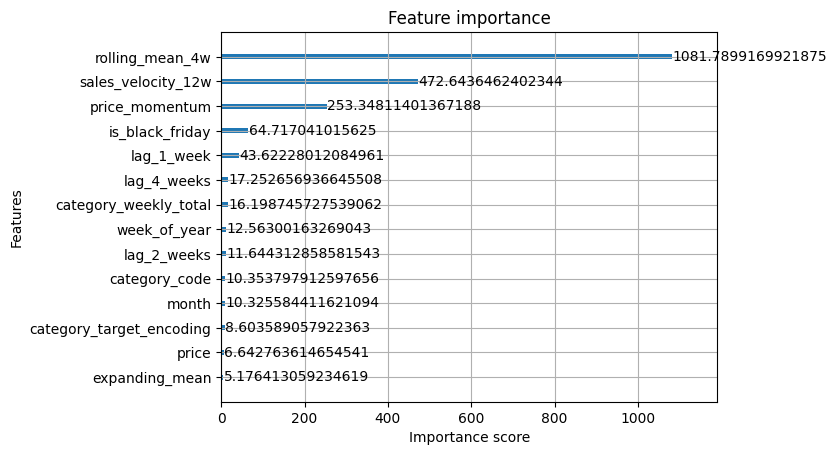

In [14]:
plt.figure(figsize=(10, 6))
plot_importance(
    reg_xgb,
    importance_type='gain',
    max_num_features=15
)
plt.show()

**Deploy best model**

In [50]:
joblib.dump(reg_xgb, "sales_forecasting_product_quantity_model.pkl")
print("✅ Model saved as sales_forecasting_product_quantity_model.pkl")

✅ Model saved as sales_forecasting_product_quantity_model.pkl
